<a href="https://colab.research.google.com/github/FideliaOsei/cs666student/blob/main/CS666_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

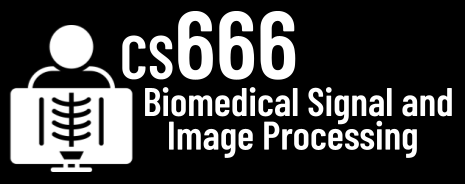
#Assignment 2

In [44]:
### TODO: YOUR NAME

Fidelia Darkoa Osei

In [45]:
%pylab inline
import os

Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['sample']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [46]:
# we will be using the EEG/MEG analysis library MNE
# documentation is available here: https://mne.tools/stable/index.html
!pip install -U mne

In [47]:
import mne # let's import MNE

# .. and the sample dataset
from mne.datasets import sample

# These data were acquired with the Neuromag Vectorview system at
# MGH/HMS/MIT Athinoula A. Martinos Center Biomedical Imaging.
# EEG data from an electrode cap was acquired simultaneously with the MEG.

### EXPERIMENT DESCRIPTION ###
# In this experiment, checkerboard patterns were presented to the subject into
# the left and right visual field, interspersed by tones to the left or right ear.
# The interval between the stimuli was 750 ms. Occasionally a smiley face was
# presented at the center of the visual field. The subject was asked to press a
# key with the right index finger as soon as possible after the appearance of the face.

In [48]:
# and let's load it!
data_path = sample.data_path()
raw = mne.io.read_raw_fif(os.path.join(data_path,'MEG/sample/sample_audvis_raw.fif'))

Opening raw data file /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.


**Task 1:** Analyze the data. [20 Points]


In [49]:
# How many EEG channels were used when acquiring the data?
# Hint: You can use raw.info or raw.ch_names to figure this out!
# TODO: YOUR ANSWER

In [50]:
eeg_channels = len(mne.pick_types(raw.info, eeg=True))
print(eeg_channels, "EEG channels were used")

59 EEG channels were used


In [51]:
# TODO What is the sampling frequency of this data?
# TODO: YOUR ANSWER

In [52]:
fs = raw.info["sfreq"]
print("The sampling frequency of the data is:", fs, "Hz")

The sampling frequency of the data is: 600.614990234375 Hz


In [53]:
# TODO What is the total duration of the measurement?
# TODO: YOUR ANSWER

In [54]:
duration = raw.times[-1]
print("Total duration used is:", duration, "s")

Total duration used is: 277.7136813300495 s


**Task 2:** Let's look at some channels! [20 Points]

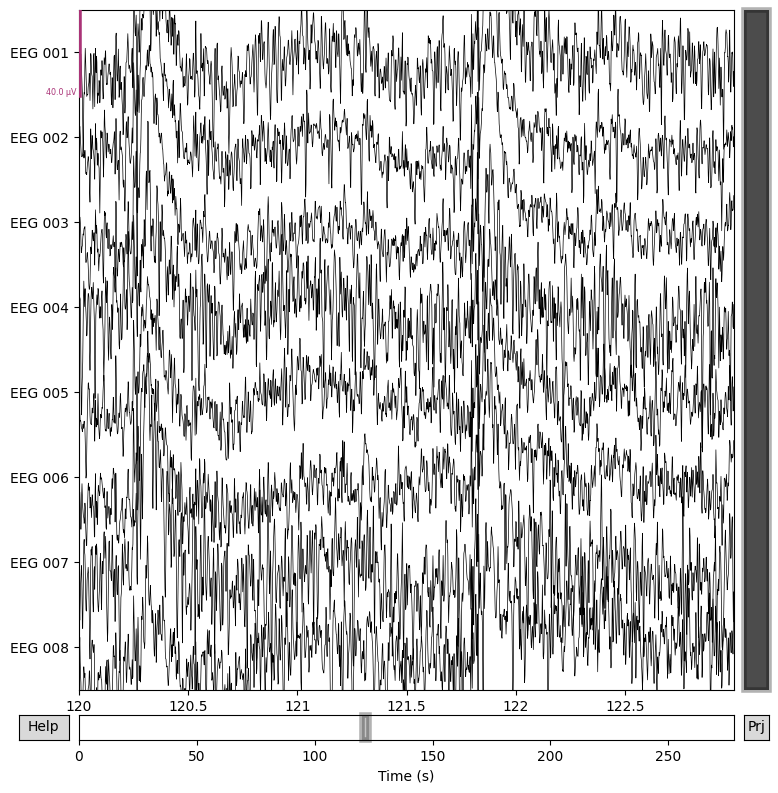

In [55]:
# the code below plots EEG channels 1-8 for 3 seconds after 2 minutes
chs = ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008']
chan_idxs = [raw.ch_names.index(ch) for ch in chs]
ecg1to8 = raw.plot(order=chan_idxs, start=120, duration=3)

In [56]:
# TODO please plot EEG channels 50-60 for 1 second after 151 seconds.

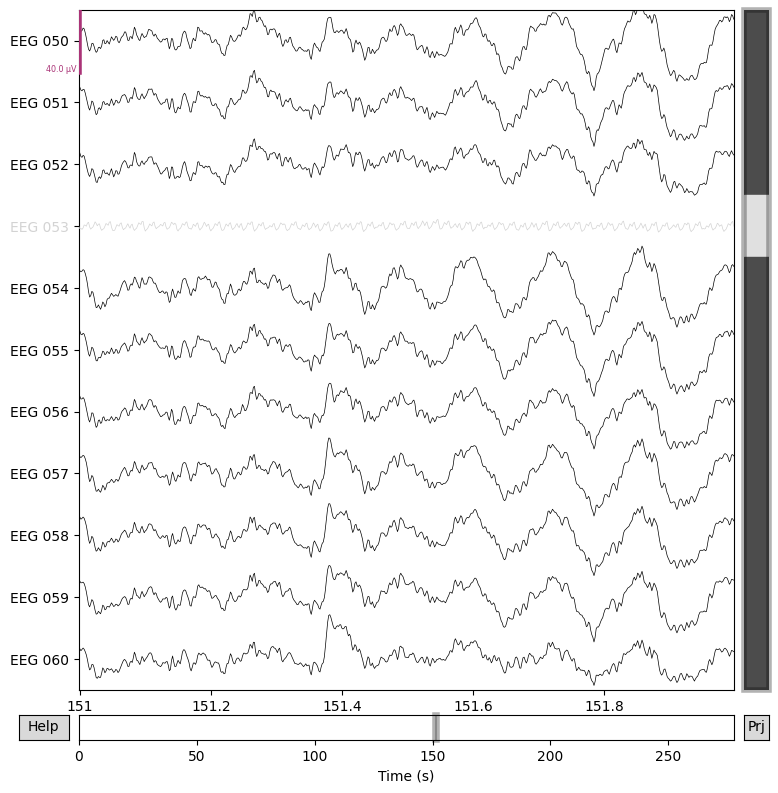

In [57]:
chs = ['EEG 050', 'EEG 051', 'EEG 052', 'EEG 053', 'EEG 054', 'EEG 055', 'EEG 056', 'EEG 057', 'EEG 058', 'EEG 059', 'EEG 060']
chan_idxs = [raw.ch_names.index(ch) for ch in chs]
eeg50to60 = raw.plot(order=chan_idxs, start=151, duration=1)


In [58]:
# TODO: Do you see a bad channel? If yes, which one?
# TODO: YOUR_ANSWER

Yes I see a bad channel, EEG 053.

In [59]:
# TODO: Please calculate the maximum value of the bad channel and compare it
# against a good channel. How would you detect a bad channel programmatically?
# Hint: See https://mne.tools/dev/generated/mne.io.Raw.html#mne.io.Raw to access
#       individual channels

In [60]:
bad_ch = "EEG 053"
good_ch = "EEG 052"

bad = raw.get_data(picks=[bad_ch])[0]
good = raw.get_data(picks=[good_ch])[0]

print("Maximum value of the bad channel (EEG 053) is:", bad.max())
print("Maximum value a of good channel (EEG 052) is:", good.max())

Maximum value of the bad channel (EEG 053) is: 6.10056150396332e-05
Maximum value a of good channel (EEG 052) is: 0.0001574162318496164


The maximum value of the bad channel (EEG 053) is much smaller than that of the good channel (EEG 052). This shows that EEG 053 has a reduced signal amplitude and is a bad channel.

A bad channel can be detected programmatically by comparing each channel's amplitude to the others. If a channel has a lower amplitude than other channels, then it is bad.

**Task 3:** How long between event and brain activity? [25 Points]

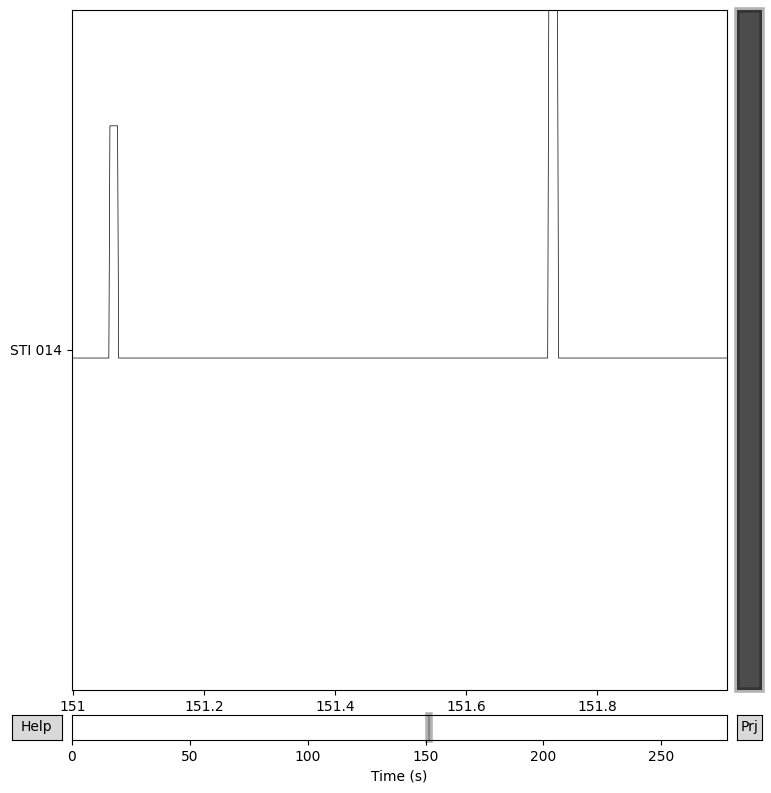

In [61]:
# the following code plots the stimulus channel for the same time
chan_idxs = [raw.ch_names.index('STI 014')]
stim = raw.plot(order=chan_idxs, start=151, duration=1)

In [62]:
# TODO Please combine the last two plots into one.
# the plot should show EEG channels 50-60 and the stimulus channel together.

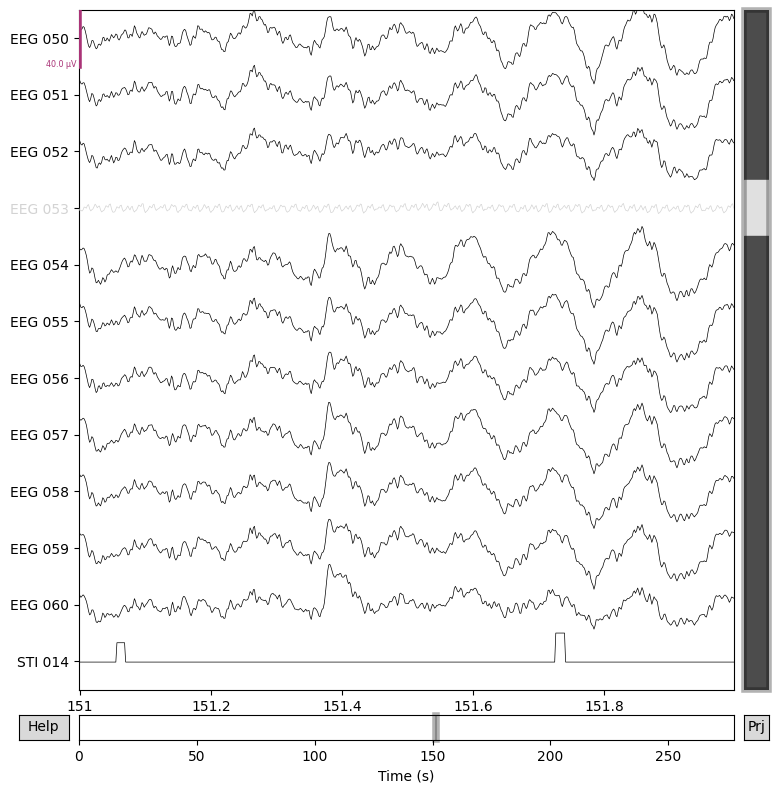

In [63]:
chs = ['EEG 050', 'EEG 051', 'EEG 052', 'EEG 053', 'EEG 054', 'EEG 055', 'EEG 056', 'EEG 057', 'EEG 058', 'EEG 059', 'EEG 060']
chs.append('STI 014')
chan_idxs = [raw.ch_names.index(ch) for ch in chs]

combined_plot = raw.plot(order=chan_idxs, start=151, duration=1)


In [64]:
# TODO How many stimulus events do you observe?
# TODO: YOUR_ANSWER

In [65]:
events = mne.find_events(raw, stim_channel='STI 014')
print("Number of stimulus events:", len(events))

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Number of stimulus events: 320


In [66]:
# TODO Please estimate the time between the first stimulus and brain activity response.
# TODO: YOUR_ANSWER

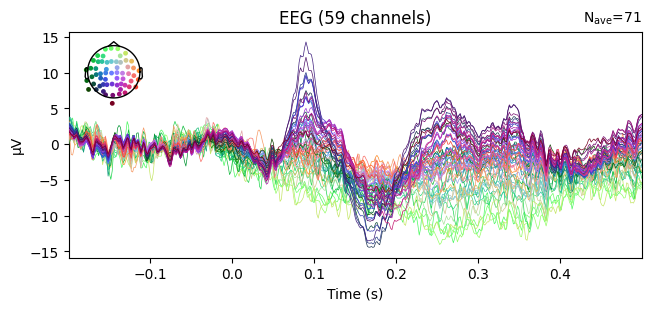

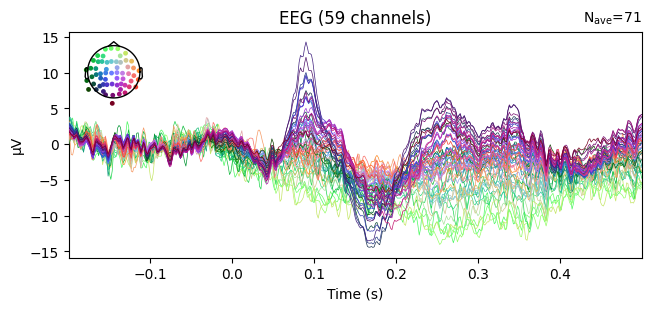

In [67]:
evoked = epochs['visual/right'].average()
evoked.plot()

The estimated time between the first stimulus and brain activity is 0.1 seconds (100ms)

**Task 4:** Localize different brain waves for different stimuli! [35 Points]

In [68]:
# the following code groups all stimuli together
# and allows the visualization of average brain activity per stimuli.
events = mne.find_events(raw, stim_channel='STI 014')
event_dict = {'auditory/left': 1,
              'auditory/right': 2,
              'visual/left': 3,
              'visual/right': 4,
              'face': 5,
              'button': 32}

picks = mne.pick_types(raw.info, eeg=True)

epochs = mne.Epochs(raw, events, event_id=event_dict, picks=picks,
                    preload=True)

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Not setting metadata
320 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Loading data for 320 events and 421 original time points ...
0 bad epochs dropped


NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


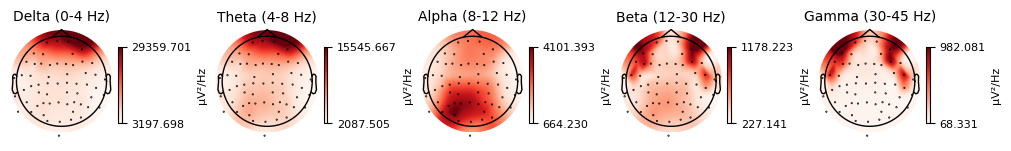

In [69]:
# here we see the average localized brain activity for the right visual stimuli
visual_activity = epochs['visual/right'].plot_psd_topomap()

NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


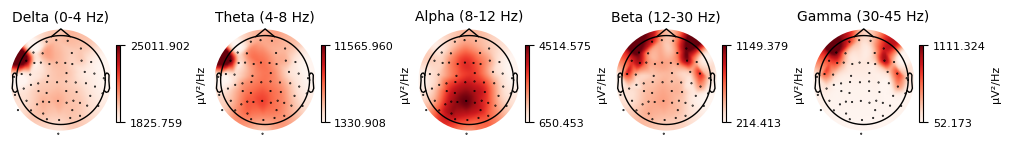

In [70]:
# here we see the average localized brain activity for the shown 'face'
face_activity = epochs['face'].plot_psd_topomap()

In [71]:
# TODO The above plots use a deprecated API call. Please re-create both plots here with the newer API.

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


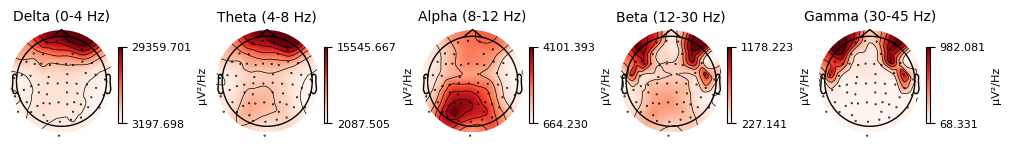

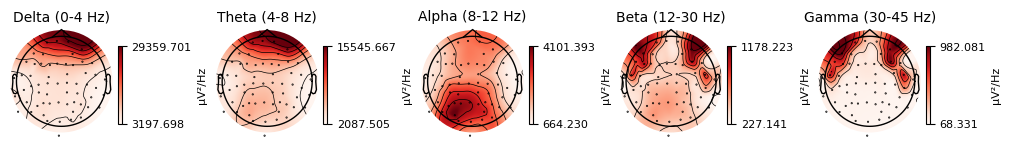

In [72]:
import mne

# Right visual stimuli: PSD topomap (new API)
psd_visual = epochs['visual/right'].compute_psd()
psd_visual.plot_topomap()

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


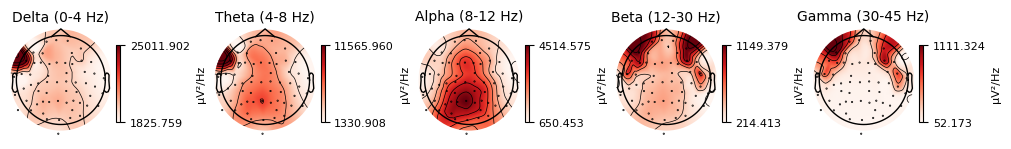

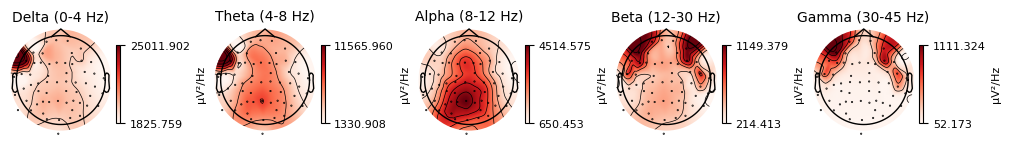

In [73]:
# Face stimuli: PSD topomap (new API)
psd_face = epochs['face'].compute_psd()
psd_face.plot_topomap()

In [74]:
# TODO Now compare the two old plots with the new ones. What are the differences?
# TODO: YOUR ANSWER

The old plots appears smoother and show less detail in the center of the scalp. The new plots shows more detailed contours and clearer spatial patterns of brain activity. The frequency bands and overall patters remain the same.

In [75]:
# TODO Please visualize the average brain activity when the subject pushes the button

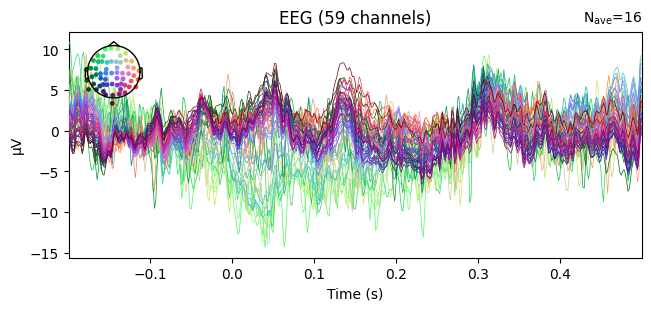

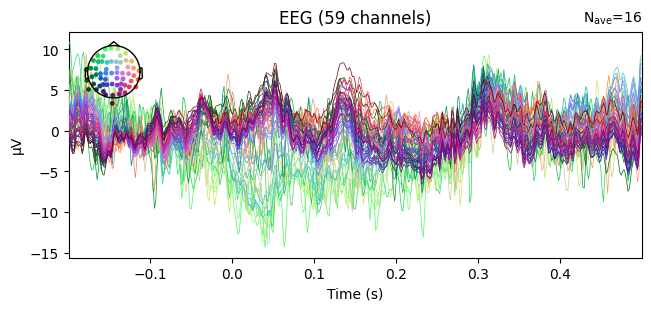

In [76]:
button_activity = epochs['button'].average()
button_activity.plot()

In [77]:
# TODO Which difference do you see between the visual/right, the face, and the button event?
# TODO Which brain region seems active during the button event?
# Hint: visual/right and face seem more similar to the button event. Think about why?
# TODO: YOUR ANSWER

The visual/right and the face events mainly show activity related to visual processing, while the button event reflects motor activity associated with pressing the button.

The experimental description mentioned that the subject presses the button with the right index finger. Since motor control is contralateral, the left motor cortex becames the active region during the button press.

The face stimulus triggers the subject to press the button, so the visual process and motor response occur close in time, making their activity patterns somewhat similar.

**Bonus Task:** What type of event happened in Task 3? [33 Points]

In [78]:
# TODO Please go back to Task 3. Can you figure out which event types happened?

In [79]:
import numpy as np

event_types = np.unique(events[:, 2])
print("Event types (IDs) present:", event_types)

Event types (IDs) present: [ 1  2  3  4  5 32]


All six events types happened. (auditory left(1), auditory right(2), visual left(3), visual right(4), face(5) and button press(32))

In [80]:
# You did it!!
#
# ┈┈┈┈┈┈▕▔╲
# ┈┈┈┈┈┈┈▏▕
# ┈┈┈┈┈┈┈▏▕▂▂▂
# ▂▂▂▂▂▂╱┈▕▂▂▂▏
# ▉▉▉▉▉┈┈┈▕▂▂▂▏
# ▉▉▉▉▉┈┈┈▕▂▂▂▏
# ▔▔▔▔▔▔╲▂▕▂▂|
#